# Homework Chapters 14 and 15 and 16

Numbers correspond to homework problems from [Introduction to Computational Physics](https://www.amazon.com/Introduction-Computational-Physics-Differential-Simulations/dp/B0FL7W88TM)


In [212]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

## Chapter 14

121. Use `solve_ivp()` to solve the following differential equation $\frac{dy}{dt} = \alpha \left( 1-y/K \right)$. Set a reasonable initial condition and graph the solution $y(t)$ for fixed values of $\alpha, K$. Make a graph that shows different values of either $\alpha$ or $K$.

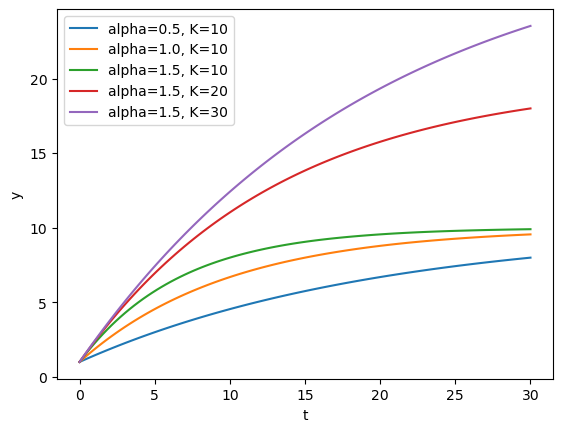

In [213]:
# Solution 121

def f(t, y, alpha=0.5, K=10):
    dy = alpha *  (1 - y / K)
    return dy
  
t_span = (0, 30)
K=10
fig, ax = plt.subplots()
for alpha in [0.5, 1.0, 1.5]:
    y0 = [1]
    sol = solve_ivp(f, t_span, y0, t_eval=np.linspace(*t_span, 100), args=(alpha, K))
    ax.plot(sol.t, sol.y[0], label=f'{alpha=}, {K=}')
alpha= 1.5
for K in [20, 30]:
    y0 = [1]
    sol = solve_ivp(f, t_span, y0, t_eval=np.linspace(*t_span, 100), args=(alpha, K))
    ax.plot(sol.t, sol.y[0], label=f'{alpha=}, {K=}')
ax.set_xlabel('t')
ax.set_ylabel('y')
ax.legend()
plt.show()



124.  For the RLC circuit, we have $L\ddot{Q} + R\dot{Q} + Q/C = 0$, **(a)** rewrite this second-order differential equation as two first-order differential equations. **(b)** write a function `def f(t,y)`, where `y` is a two-dimensional variable (representing the two time-dependent variables). **(c)** Use `solve_ivp()` to solve for $Q(t)$ and **(d)** graph the charge $Q$ versus time $t$ for multiple oscillations, choosing appropriate values. 

In [214]:
# Solution 124 **(a)** rewrite this second-order differential equation as two first-order differential equations. 

# dQ/dt = I
# dI/dt = (- R*I - Q/C) / L

In [215]:
# Solution 124  **(b)** write a function `def f(t,y)`, where `y` is a two-dimensional variable (representing the two time-dependent variables). 
def f(t, y, R=1.0, C=1.0, L=1.0):
    Q, I = y
    dQ = I
    dI = (- R*I - Q/C) / L
    return [dQ, dI]
  

In [216]:
# Solution 124  **(c)** Use `solve_ivp()` to solve for $Q(t)$ and **(d)** graph the charge $Q$ versus time $t$ for multiple oscillations, choosing appropriate values. 
R0, C0, L0 = 1.0, 1.0, 1.0
sol = solve_ivp(f, (0, 20), [1, 0], t_eval=np.linspace(0, 20, 1000), args=(R0,C0,L0))
sol 

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  2.002e-02 ...  1.998e+01  2.000e+01]
        y: [[ 1.000e+00  9.998e-01 ... -2.615e-05 -2.509e-05]
            [ 0.000e+00 -1.982e-02 ...  5.312e-05  5.257e-05]]
      sol: None
 t_events: None
 y_events: None
     nfev: 152
     njev: 0
      nlu: 0

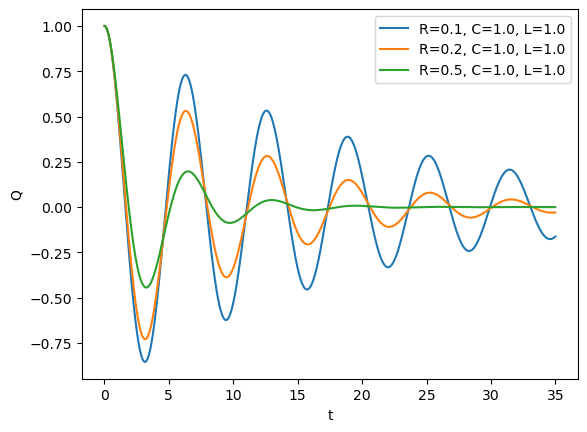

In [217]:
# Solution 124  **(d)** graph the charge $Q$ versus time $t$ for multiple oscillations, choosing appropriate values. 
fig, ax = plt.subplots()
R,C,L = 1.0, 1.0, 1.0
tf = 35
for R in [0.1,0.2,0.5]:
    sol = solve_ivp(f, (0, tf), [1, 0], t_eval=np.linspace(0, tf, 1000), args=(R, 1.0, 1.0))
    ax.plot(sol.t, sol.y[0], label=f'{R=}, {C=}, {L=}')

ax.set_xlabel('t')
ax.set_ylabel('Q')
ax.legend()
plt.show()  

## Chapter 15

In the Lotka-Volterra [predator-prey model](https://en.wikipedia.org/wiki/Lotka%E2%80%93Volterra_equations) the populations of two dependent species $[y_1, y_2]$ vary as follows:

$$
\frac{dy_1}{dt} = \alpha y_1 - \beta y_1 y_2, \quad
\frac{dy_2}{dt} = -\gamma y_2 + \delta y_1 y_2
$$

125. Use the Lotka-Volterra equation  and add damping to model environmental resistance $K$, as in $\frac{dx}{dt} = \alpha x \left( 1 - \frac{x}{K} \right) - \beta x y$. Use `solve_ivp()` to solve for populations $x(t)$ and $y(t)$. For prey values use $\alpha=1.5$ and $\beta=0.1$, for predators use $\gamma =1.5$ and $\delta=0.07$. Explore values for $K$ from 10 to 100 and explain its meaning.

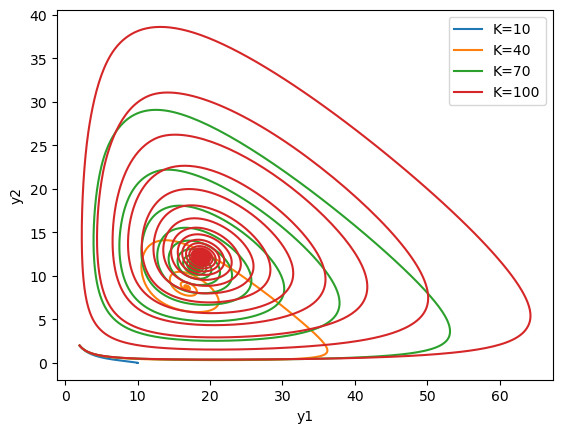

In [218]:
# Solution 125
def Lotkavolterra(t, y, K, alpha=1.0, beta=0.1, delta=0.1, gamma=1.0):
    y1, y2 = y
    dy1 = alpha * y1*(1-y1/K) - beta * y1 * y2
    dy2 =  - gamma * y2*(1-y2/K) + delta * y1 * y2
    return [dy1, dy2] 
  
t_span = (0, 200)
alpha= 1.5
beta= 0.1
delta= 0.07
gamma= 1.5
K = 0 

fig, ax = plt.subplots()
for K in np.linspace(10,100,4):
    y0 = [2, 2]
    sol = solve_ivp(Lotkavolterra, t_span, y0, t_eval=np.linspace(*t_span, 10000), args=(K, alpha, beta, delta, gamma))
    ax.plot(sol.y[0], sol.y[1], label=f'K={K:.0f}')

ax.set_xlabel('y1')
ax.set_ylabel('y2')  
ax.legend()
plt.show()

126. A radioactive isotope decays over time; this can be modeled with $\dot{N} = -\lambda N$. For a material with 1000 starting nuclei and a half-life of $T_{1/2} =$ 12 seconds, find $\lambda$.  **(a)** Graph $N(t)$ for the first 80 seconds using `solve_ivp()`.  **(b)** Determine numerically the time, when 90% of the sample has decayed. **(c)** Use random numbers to simulate the decay over 80s in $\Delta t=$ 1 s intervals. For each individual isotope, the probability to decay after $\Delta t$ is $P = \lambda \Delta t$. Use a random number to determine, whether the isotope decays and keep track of the total number of isotopes that have not decayed yet.

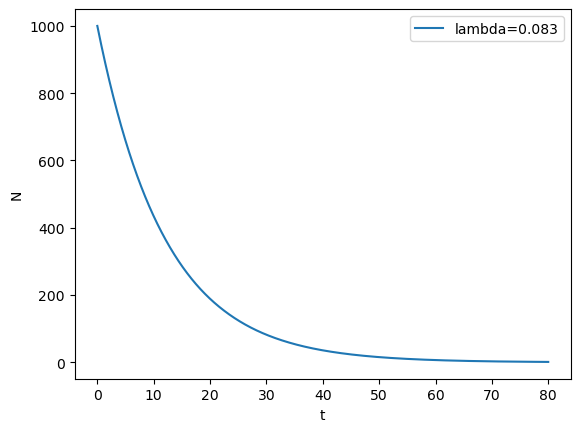

In [219]:
# Solution 126 part (a) Graph
N0 = 1000
def f(t, N, l=1/12): 
  dN = -l*N
  return dN
t_span = (0, 80)
l0 = 1/12
sol = solve_ivp(f, t_span, [N0], t_eval=np.linspace(*t_span, 10000), args=(l0,))
fig, ax = plt.subplots()
ax.plot(sol.t, sol.y[0], label=f'lambda={l0:.3f}')
ax.set_xlabel('t')
ax.set_ylabel('N')
ax.legend()
plt.show()  

In [220]:
# Solution 126 part (b)
N_stop = 0.1*N0
t_vec, N_vec = sol.t, sol.y[0]
m=0
while N_stop < N_vec[m]:
    m += 1
print(f'90% of the sample has decayed after {t_vec[m]:.2f} seconds, we have {N_vec[m]:.0f} atoms remaining.')

90% of the sample has decayed after 27.64 seconds, we have 100 atoms remaining.


In [221]:
1 * (np.random.rand(10) > l0) * (np.random.rand(10) > l0) * (np.random.rand(10) > l0), l0

(array([1, 1, 1, 1, 1, 0, 1, 1, 1, 1]), 0.08333333333333333)

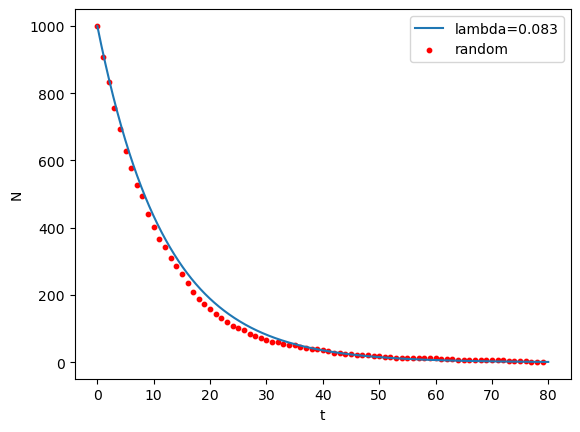

In [222]:
# Solution 126 part (c)
dt = 1  # 1 second time steps

N2 = [N0]
N_pop = np.ones(N0)
for t in range(79):
    N_pop = N_pop * (np.random.rand(N0) > (l0*dt))
    N2.append(int(N_pop.sum()))

fig, ax = plt.subplots()
ax.plot(sol.t, sol.y[0], label=f'lambda={l0:.3f}')
ax.scatter(range(80), N2, label='random', color='red', s=10)
ax.set_xlabel('t')
ax.set_ylabel('N')
ax.legend()
plt.show()  

## Chapter 16 (OPTIONAL)

The time-independent Schr&ouml;dinger equation is a second-order differential equation. It boils down to a wave equation with boundary values.  Let us concentrate on the 1D case for this illustration and solve for the wave function $\psi(x)$:  

$$
-\frac{\hbar^2}{2m} \frac{d^2}{dx^2} \psi + V(x) \psi = E \psi
$$

We apply  Verlet method  to rewrite the dimensionless Schrödinger equation using discrete elements each separated in distance by $\Delta y$.  

$$
-\frac{\psi_{j+1} - 2\psi_j + \psi_{j-1}}{\Delta y^2} +  \mu V_j  \psi_j = \mu E \psi_j
$$  

This represents a set of equations that can be solved with linear algebra. In a first approach, use $\Delta y=0.2$ which means that we have $j=0, \ldots, 5$, This choice keeps the size of the matrix at bay, but still shows us the essentials. Secondly, for now, we assume that $V(x)=0$ for all $0<x<1$. More interesting numerical solutions maybe obtained, if we modify the potential $V(x)$ in this interval.

$$
\psi_{j+2} - 2\psi_{j+1} + \psi_j = - 
\mu E \; \psi_{j+1}
$$ 

$$
\begin{pmatrix} 
2 & -1 & 0 & 0 & 0 & 0 \\
-1 & 2 & -1 & 0 & 0 & 0 \\
0 & -1 & 2 & -1 & 0 & 0 \\ 
0 & 0 & -1 & 2 & -1 & 0 \\ 
0 & 0 & 0 & -1 & 2 & -1 \\ 
0 & 0 & 0 & 0 & -1 & 2 \\ 
\end{pmatrix}
\begin{pmatrix}
\psi_0 \\
\psi_1 \\
\psi_2 \\
\psi_3 \\
\psi_4 \\
\psi_5 \\
\end{pmatrix}
=
\mu E
\begin{pmatrix}
\psi_0 \\
\psi_1 \\
\psi_2 \\
\psi_3 \\
\psi_4 \\
\psi_5 \\
\end{pmatrix}
$$ 

This system of equations is solved by finding the eigenvectors and eigenvalues.

129.   Solve the 1D Schr&ouml;dinger equation numerically for a `100 x 100` matrix. Find the lowest 10 energy levels and their corresponding wave functions. Graph the three lowest energy wave functions. (Optional: implement the harmonic oscillator potential $V(x)$ and solve for the discrete energy levels.)

In [223]:
# Solution 129 (OPTIONAL)

# see solution in book

The End.